# REPSOL Model Training (70/15/15)

**EfficientNet-05 — CONTROL EXPERIMENT: run-02 baseline config on the fixed dataset**

Purpose: isolate how much of the run-04 improvement came from the **data fix** vs the
**anti-overfitting package**. This run replicates EfficientNet-02 exactly — same `Trainer`
class, same hyperparameters, no augmentation, no freezing, no label smoothing, checkpoint
on val loss — with only ONE change: it trains on `Data/Spectrograms_224` (full spectrogram)
instead of the broken first-400-columns view.

| | EfficientNet-02 | EfficientNet-05 (this) | EfficientNet-04 |
|---|---|---|---|
| Data | first 400/3156 cols | **full spectrogram 224×224** | full spectrogram 224×224 |
| Config | baseline | **baseline (identical)** | SpecAugment + freeze + macro-F1 + wd 1e-2 |
| Test acc | 68–70% | ? | 83.2% |

Reading the result:
- **05 ≫ 02** → the data fix itself carries that much improvement
- **04 > 05** gap → the regularisation package's contribution
- If 05 overfits hard (like 02/03 did), that confirms augmentation/freezing still matter on the fixed data

Config (verbatim from EfficientNet-02): batch 8, epochs 15, LR 1e-3, patience 4,
sklearn balanced class weights, AdamW wd 1e-4, ReduceLROnPlateau on val loss,
full backbone fine-tuning.

## 0. Config

In [1]:
from pathlib import Path
import sys
import torch

# ===== Hyperparameters — IDENTICAL to EfficientNet-02, do not tune =====
BATCH_SIZE = 8
EPOCHS     = 15
LEARNING_RATE = 1e-3
PATIENCE   = 4
MODEL_NAME = "efficientnet_05"

# ===== Paths =====
PROJECT_ROOT    = Path(r"D:\\Work\\Internships\\INMAR\\REPSOL")
SPECTROGRAM_DIR = PROJECT_ROOT / "Data" / "Spectrograms_224"   # <-- the ONLY change vs run-02
OUTPUT_DIR      = PROJECT_ROOT / "Models_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))


def next_run_path(model_name, suffix, ext, output_dir):
    prefix = f"{model_name}{suffix}"
    existing = [0]
    for p in output_dir.iterdir():
        if not p.is_file() or p.suffix != ext:
            continue
        stem = p.stem
        if stem.startswith(prefix + "_"):
            tail = stem[len(prefix) + 1:]
            if tail.isdigit():
                existing.append(int(tail))
    return output_dir / f"{prefix}_{max(existing)+1:02d}{ext}"


CHECKPOINT_PATH = next_run_path(MODEL_NAME, "_best", ".pth", OUTPUT_DIR)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("DEVICE         :", DEVICE)
print(f"BATCH_SIZE={BATCH_SIZE}  EPOCHS={EPOCHS}  LR={LEARNING_RATE}  PATIENCE={PATIENCE}")

CHECKPOINT_PATH: D:\Work\Internships\INMAR\REPSOL\Models_output\efficientnet_05_best_01.pth
DEVICE         : cpu
BATCH_SIZE=8  EPOCHS=15  LR=0.001  PATIENCE=4


## 1. Verify Data

In [2]:
def count_pt_files(root):
    counts = {}
    for split in ["train", "val", "test"]:
        split_dir = root / split
        counts[split] = sum(1 for _ in split_dir.rglob("*.norm.pt")) if split_dir.exists() else 0
    return counts

counts = count_pt_files(SPECTROGRAM_DIR)
print("Tensor files by split:", counts)
print("Total:", sum(counts.values()))

assert counts["train"] > 0, "No train .norm.pt files found — run src/preprocess/downsize_spectrograms.py first."
assert counts["val"]   > 0, "No val .norm.pt files found."
assert counts["test"]  > 0, "No test .norm.pt files found."

sample = next((SPECTROGRAM_DIR / "train").rglob("*.norm.pt"))
t = torch.load(sample)
print(f"Sample shape: {tuple(t.shape)}  mean={t.mean():.3f}  std={t.std():.3f}")
assert t.shape[-2:] == (224, 224), f"Expected 224x224 tensors, got {tuple(t.shape)}"

Tensor files by split: {'train': 1382, 'val': 296, 'test': 297}
Total: 1975
Sample shape: (3, 224, 224)  mean=-0.000  std=1.000


## 2. Training (run-02 Trainer, unchanged config)

In [3]:
import importlib
import torch

import src.EfficientNet.model as model_module
import src.EfficientNet.train as train_module

model_module = importlib.reload(model_module)
train_module = importlib.reload(train_module)
Trainer = train_module.Trainer

trainer = Trainer(
    spectrogram_dir=SPECTROGRAM_DIR,
    checkpoint_path=CHECKPOINT_PATH,
    model_name="efficientnet",   # model factory name, NOT the run name
    batch_size=BATCH_SIZE,
    max_epochs=EPOCHS,
    patience=PATIENCE,
    lr=LEARNING_RATE,
    device=DEVICE,
    target_width=None,           # 224x224 tensors — don't pad/crop to 400
)

trainer.fit()

Train samples: 1382
Train batches: 173


Epoch 1/15 Validation: 100%|████████████████████████| 37/37 [00:11<00:00,  3.21batch/s, loss=1.1424]

Epoch 1/15 | Train Loss: 1.3865 | Val Loss: 1.4741 | Train Acc: 50.87 | Val Acc: 48.31
Saved improved checkpoint to: D:\Work\Internships\INMAR\REPSOL\Models_output\efficientnet_05_best_01.pth



Epoch 2/15 Validation: 100%|████████████████████████| 37/37 [00:11<00:00,  3.19batch/s, loss=1.1758]

Epoch 2/15 | Train Loss: 1.0814 | Val Loss: 0.8539 | Train Acc: 59.12 | Val Acc: 66.89
Saved improved checkpoint to: D:\Work\Internships\INMAR\REPSOL\Models_output\efficientnet_05_best_01.pth


...

Epoch 12/15 | Train Loss: 0.0515 | Val Loss: 0.9716 | Train Acc: 97.83 | Val Acc: 80.41
No improvement for 2/4 epochs



Epoch 13/15 Validation: 100%|███████████████████████| 37/37 [00:11<00:00,  3.35batch/s, loss=0.3598]

Epoch 13/15 | Train Loss: 0.0444 | Val Loss: 0.8747 | Train Acc: 97.97 | Val Acc: 82.09
No improvement for 3/4 epochs



Epoch 14/15 Validation: 100%|███████████████████████| 37/37 [00:11<00:00,  3.22batch/s, loss=1.8509]

Epoch 14/15 | Train Loss: 0.0220 | Val Loss: 0.9840 | Train Acc: 99.28 | Val Acc: 82.09
No improvement for 4/4 epochs
Early stopping: no improvement for 4 epochs.
Training finished.


## 3. Evaluation

In [4]:
import importlib
import src.evaluate as eval_module

eval_module = importlib.reload(eval_module)
evaluate_model = eval_module.evaluate_model

state = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
trainer.model.load_state_dict(state)

val_metrics  = evaluate_model(trainer.model, trainer.val_loader,  DEVICE)
test_metrics = evaluate_model(trainer.model, trainer.test_loader, DEVICE)

print("Validation:")
print({k: round(val_metrics[k], 4) for k in ["accuracy", "precision", "recall", "f1"]})
print("\nTest:")
print({k: round(test_metrics[k], 4) for k in ["accuracy", "precision", "recall", "f1"]})

Validation:
{'accuracy': 0.8446, 'precision': 0.8547, 'recall': 0.8446, 'f1': 0.8449}

Test:
{'accuracy': 0.8114, 'precision': 0.8226, 'recall': 0.8114, 'f1': 0.8138}


In [5]:
print("Test Classification Report:\n")
print(test_metrics["report"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

Test Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.57      0.67      0.62         6
           2       0.81      0.85      0.83        20
           3       0.85      0.75      0.79       106
           4       0.62      0.79      0.70        39
           5       1.00      0.91      0.95        11
           6       0.84      0.88      0.86        76
           7       1.00      0.83      0.91         6

    accuracy                           0.81       297
   macro avg       0.82      0.82      0.82       297
weighted avg       0.82      0.81      0.81       297

Confusion Matrix:
[[28  0  0  2  2  0  1  0]
 [ 0  4  0  2  0  0  0  0]
 [ 0  0 17  1  2  0  0  0]
 [ 1  1  1 79 15  0  9  0]
 [ 0  0  3  2 31  0  3  0]
 [ 0  1  0  0  0 10  0  0]
 [ 2  1  0  6  0  0 67  0]
 [ 0  0  0  1  0  0  0  5]]


## 4. Learning Curves

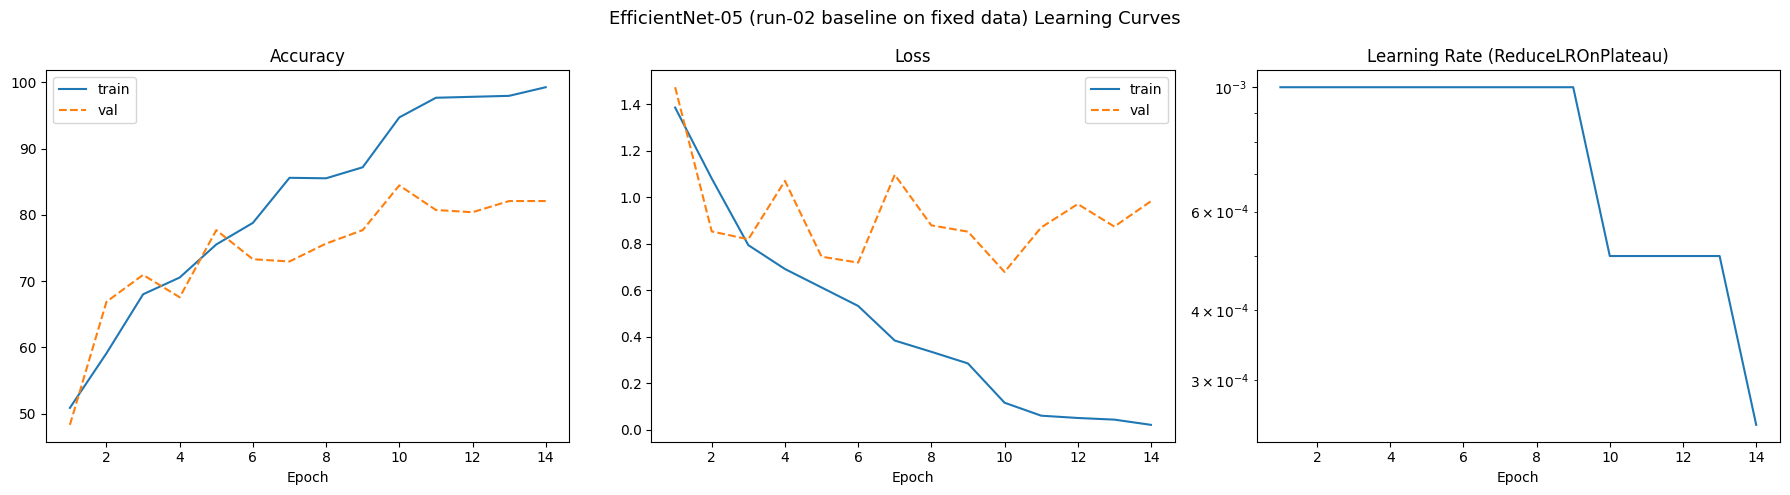

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

HISTORY_PATH = CHECKPOINT_PATH.with_name(f"{CHECKPOINT_PATH.stem}_training_history.csv")
df = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df["epoch"], df["train_acc"], label="train")
axes[0].plot(df["epoch"], df["val_acc"],   label="val", linestyle="--")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train_loss"], label="train")
axes[1].plot(df["epoch"], df["val_loss"],   label="val", linestyle="--")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["lr"])
axes[2].set_title("Learning Rate (ReduceLROnPlateau)"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

fig.suptitle("EfficientNet-05 (run-02 baseline on fixed data) Learning Curves", fontsize=13)
fig.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "evaluation" / "learning_curves_efficientnet_05.png",
            dpi=150, bbox_inches="tight")
plt.show()